# **Hyperparameter Tuning**

In [ ]:
sweep_config = {
    'name': 'attention_sweep',
    'method': 'grid',
    'metric': {'name': 'val_loss', 'goal': 'minimize'},
    'parameters': {
        'epochs': {'values': [5, 10]},
        'embedding_dim': {'values': [256, 512]},
        'num_layers': {'values': [1,2]},
        'num_heads': {'values': [4, 8]},
        'dropout': {'values': [0.2]},
        'batch_size': {'values': [32]},
        'learning_rate': {'values': [10e-4]},
        
    }
}

In [ ]:
# Run python attention/attention_sweep.py

# **Testing Best Model**

In [13]:
import torch
import importlib
import attention
import load_data
import torch.nn as nn

# Reload both modules
importlib.reload(attention)
importlib.reload(load_data)

# Re-import after reload
from attention import DualAttentionSeq2Seq
from load_data import get_data_loaders

# Load data (Latin → Devanagari)
train_loader, dev_loader, test_loader, char_to_idx_latin, char_to_idx_devanagari = get_data_loaders()

# Vocabulary info
input_vocab_size = len(char_to_idx_latin)
output_vocab_size = len(char_to_idx_devanagari)
idx_to_input = {v: k for k, v in char_to_idx_latin.items()}
idx_to_output = {v: k for k, v in char_to_idx_devanagari.items()}
# Index maps
idx_to_latin = {v: k for k, v in char_to_idx_latin.items()}
idx_to_devanagari = {v: k for k, v in char_to_idx_devanagari.items()}
# Device
device = torch.device("cuda")

# Model
model = DualAttentionSeq2Seq(
    input_vocab_size=input_vocab_size,
    output_vocab_size=output_vocab_size,
    embedding_dim=256,
    hidden_dim=256,
    num_layers=1,
    num_heads=4,
    dropout=0.2,
    device=device
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

# Training loop
best_val_loss = float('inf')
for epoch in range(10):
    model.train()
    train_loss = 0
    
    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)

        output = model(src, trg[:, :-1])  # teacher forcing
        loss = criterion(
            output.reshape(-1, output_vocab_size),
            trg[:, 1:].reshape(-1)
        )
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item()
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in dev_loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg[:, :-1])
            val_loss += criterion(
                output.reshape(-1, output_vocab_size),
                trg[:, 1:].reshape(-1)
            ).item()
    
    val_loss /= len(dev_loader)
    print(f'Epoch {epoch+1}: Train Loss = {train_loss/len(train_loader):.4f}, Val Loss = {val_loss:.4f}')
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_attention_model.pt')
        print("Saved new best model")




Epoch 1: Train Loss = 0.4749, Val Loss = 0.0643
Saved new best model
Epoch 2: Train Loss = 0.1980, Val Loss = 0.0471
Saved new best model
Epoch 3: Train Loss = 0.1290, Val Loss = 0.0359
Saved new best model
Epoch 4: Train Loss = 0.0950, Val Loss = 0.0280
Saved new best model
Epoch 5: Train Loss = 0.0762, Val Loss = 0.0280
Saved new best model
Epoch 6: Train Loss = 0.0682, Val Loss = 0.0241
Saved new best model
Epoch 7: Train Loss = 0.0629, Val Loss = 0.0258
Epoch 8: Train Loss = 0.0555, Val Loss = 0.0328
Epoch 9: Train Loss = 0.0553, Val Loss = 0.0184
Saved new best model
Epoch 10: Train Loss = 0.0543, Val Loss = 0.0228


In [14]:
# Load best model
model.load_state_dict(torch.load('best_attention_model.pt'))

# Helper: Decode sequence
def decode_sequence(indices, idx_to_char):
    return ''.join([idx_to_char.get(idx, '') for idx in indices if idx not in {0, 1, 2}])

# Testing loop
model.eval()
test_loss = 0
exact_matches = 0
total_sequences = 0
all_predictions = []  # Store ALL predictions

with torch.no_grad():
    for src, trg in test_loader:
        src, trg = src.to(device), trg.to(device)
        output = model(src, trg[:, :-1])

        # Loss calculation
        test_loss += criterion(
            output.reshape(-1, output_vocab_size),
            trg[:, 1:].reshape(-1)
        ).item()
        
        # Get predictions
        _, predicted = output.max(2)
        batch_size = predicted.size(0)
        
        for i in range(batch_size):
            input_seq = decode_sequence(src[i].cpu().numpy(), idx_to_latin)
            pred_seq = decode_sequence(predicted[i].cpu().numpy(), idx_to_devanagari)
            true_seq = decode_sequence(trg[i, 1:].cpu().numpy(), idx_to_devanagari)
            
            if pred_seq == true_seq:
                exact_matches += 1
            total_sequences += 1
            
            all_predictions.append((input_seq, pred_seq, true_seq))

# Calculate metrics
test_loss /= len(test_loader)
accuracy = exact_matches / total_sequences

# Print summary
print(f'\nTest Loss: {test_loss:.4f}, Exact Match Accuracy: {accuracy:.2%}')
print(f'Total Test Examples: {total_sequences}')

# Save ALL predictions to TSV (overwrites existing file)
with open("predictions_attention.tsv", "w", encoding="utf-8") as f:
    f.write("latin\tpredicted\tground_truth\n")
    for input_seq, pred_seq, true_seq in all_predictions:
        f.write(f"{input_seq}\t{pred_seq}\t{true_seq}\n")

print("\nFirst 10 Example Predictions:")
for i, (input_seq, pred_seq, true_seq) in enumerate(all_predictions[:10]):
    status = "✓" if pred_seq == true_seq else "✗"
    print(f"{i+1}. Input: {input_seq}")
    print(f"   Pred: {pred_seq}")
    print(f"   True: {true_seq} ({status})\n")

print(f"Saved ALL {total_sequences} predictions to predictions_attention.tsv")


Test Loss: 0.0237, Exact Match Accuracy: 96.69%
Total Test Examples: 4502

First 10 Example Predictions:
1. Input: ank
   Pred: अंक
   True: अंक (✓)

2. Input: anka
   Pred: अंक
   True: अंक (✓)

3. Input: ankit
   Pred: अंकित
   True: अंकित (✓)

4. Input: anakon
   Pred: अंकों
   True: अंकों (✓)

5. Input: ankhon
   Pred: अंकों
   True: अंकों (✓)

6. Input: ankon
   Pred: अंकों
   True: अंकों (✓)

7. Input: angkor
   Pred: अंकोर
   True: अंकोर (✓)

8. Input: ankor
   Pred: अंकोर
   True: अंकोर (✓)

9. Input: angaarak
   Pred: अंगारक
   True: अंगारक (✓)

10. Input: angarak
   Pred: अंगारक
   True: अंगारक (✓)

Saved ALL 4502 predictions to predictions_attention.tsv


# **Visualisation**

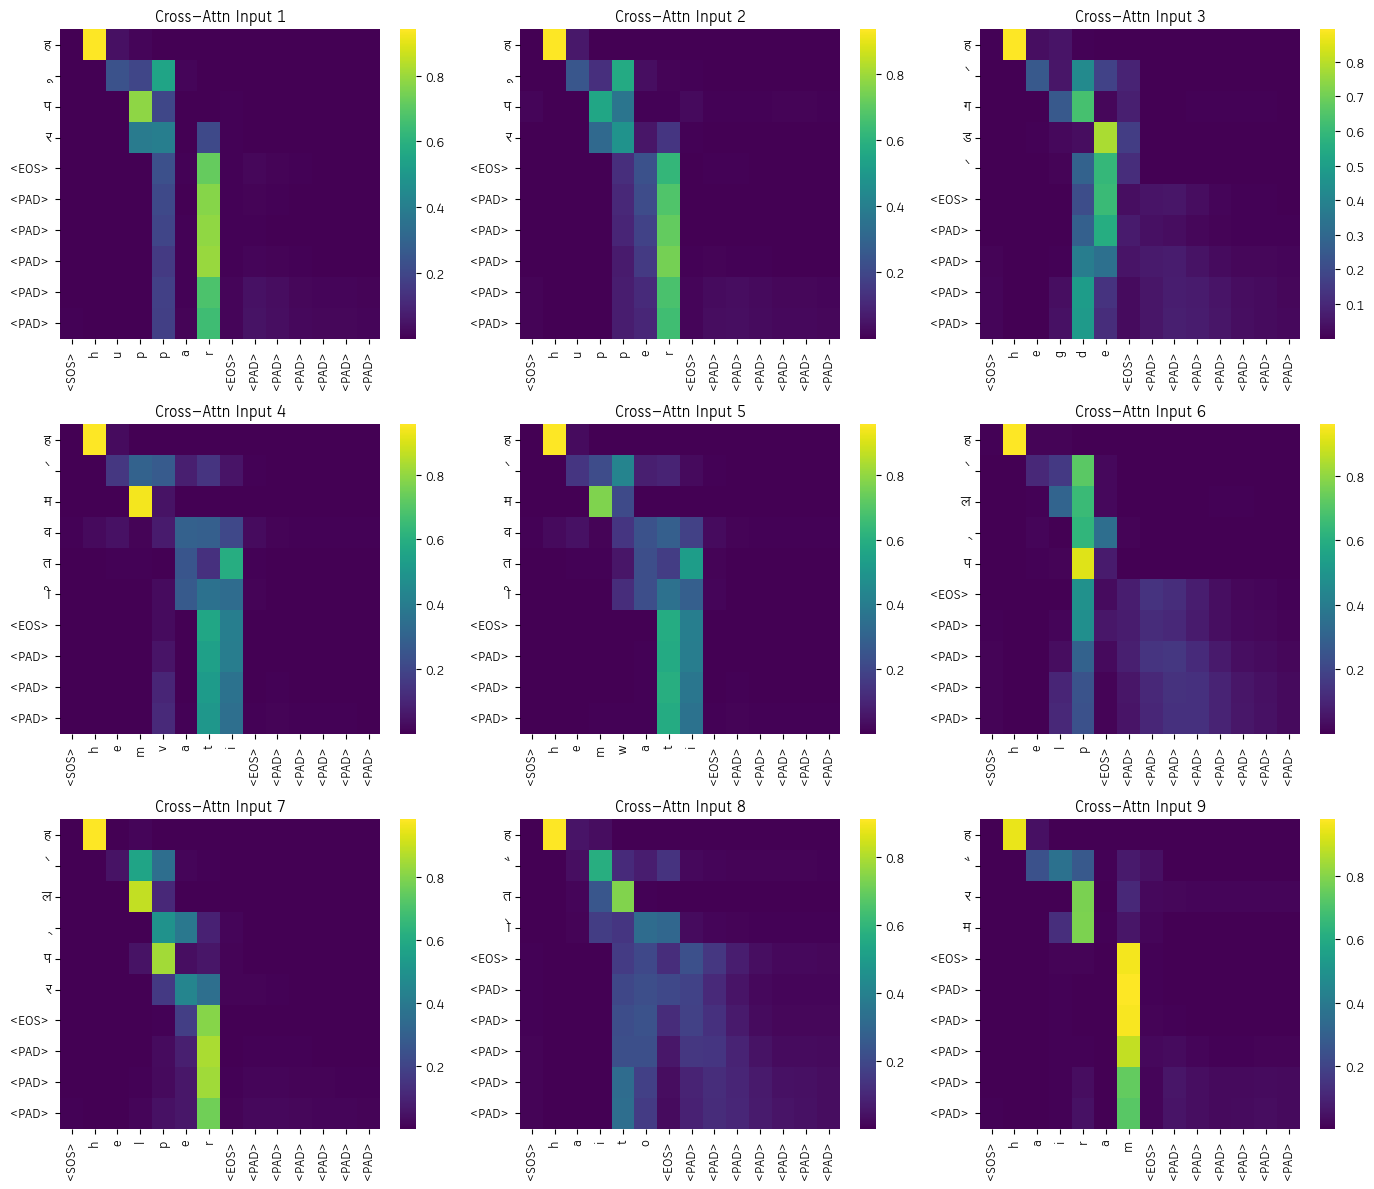

In [15]:

from attention import plot_cross_attention_heatmaps

fig = plot_cross_attention_heatmaps(model, src, trg, idx_to_input, idx_to_output)

In [16]:

from attention import interactive_dualline_attention
fig = interactive_dualline_attention(model, src, trg, idx_to_input, idx_to_devanagari, idx_to_latin)



In [ ]:
import wandb
import plotly.io as pio
import tempfile
import os


wandb.init(project="transliteration-sweep")

# Save the interactive plot as a temporary HTML file
with tempfile.NamedTemporaryFile(suffix=".html", delete=False) as tmpfile:
    pio.write_html(fig, file=tmpfile.name, auto_open=False)
    html_path = tmpfile.name

# Log it to wandb
wandb.log({"Interactive Attention Plot": wandb.Html(open(html_path))})

# Optional: clean up temporary file if desired
os.remove(html_path)
